# EDA по [датасету](https://www.kaggle.com/datasets/shivamb/netflix-shows) о проектах на платформе **Netflix**

## 1. Чтение данных из .csv файла

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv("netflix_titles.csv")

df.head()
df.tail()

## 2. Первичный анализ данных

In [ ]:
df.shape    # размер таблицы
df.info()   # информация о типах данных в таблице
df.describe(include='all') # статистика о таблице

## 3. Проверка качества данных

### 3.1 Проверка пустых данных

In [ ]:
df.isnull().sum().sort_values(ascending=False)
sns.heatmap(df.isnull(), cbar=False)
plt.show()
df.dropna()

### 3.2 Проверка на дубликаты

In [ ]:
df.duplicated().sum()

### 3.3 Проверка категорий

In [ ]:
df['type'].value_counts()
df['rating'].value_counts()
df['country'].value_counts()
df['release_year'].value_counts()
df['director'].value_counts()

### 3.4 Проверка логистических ошибок

In [ ]:
df[df['release_year'] > 2026]
df[df['title'].isna()]

## 4. Обработка данных
### 4.1 Обработка даты

In [ ]:
if not pd.api.types.is_datetime64_any_dtype(df['date_added']):
    df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y')

### 4.2 Обработка длительности

In [ ]:
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_type'] = df['duration'].str.extract(r'([A-Za-z]+)')
df.head(10)

### 4.3 Обработка жанров

In [ ]:
df['genre_main'] = df['listed_in'].str.split(',').str[0]
df.head(10)

## 4.4 Обработка стран

In [27]:
df['country_main'] = df['country'].str.split(',').str[0]
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num,duration_type,genre_main,country_main
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,min,Documentaries,United States
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,Seasons,International TV Shows,South Africa
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0,Season,Crime TV Shows,Unknown
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0,Season,Docuseries,Unknown
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0,Seasons,International TV Shows,India
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,1.0,Season,TV Dramas,Unknown
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91.0,min,Children & Family Movies,Unknown
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125.0,min,Dramas,United States
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,9.0,Seasons,British TV Shows,United Kingdom
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104.0,min,Comedies,United States


## 4.5 Возраст фильма на момент добавления

In [32]:
df['content-age'] = df['date_added'].dt.year - df['release_year']
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num,duration_type,genre_main,country_main,content-age
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,min,Documentaries,United States,1.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,Seasons,International TV Shows,South Africa,0.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0,Season,Crime TV Shows,Unknown,0.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0,Season,Docuseries,Unknown,0.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0,Seasons,International TV Shows,India,0.0
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,1.0,Season,TV Dramas,Unknown,0.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91.0,min,Children & Family Movies,Unknown,0.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125.0,min,Dramas,United States,28.0
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,9.0,Seasons,British TV Shows,United Kingdom,0.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104.0,min,Comedies,United States,0.0


## 5. Работа с пропусками

In [ ]:
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df.head(10)

## 6. Основные визуализации
### 6.1 Распределение типов контента

In [ ]:

px.histogram(df, x='type', title="Distribution of Content Type")

### 6.2 Контент по годам

Text(0.5, 1.0, 'Content release date distribution')

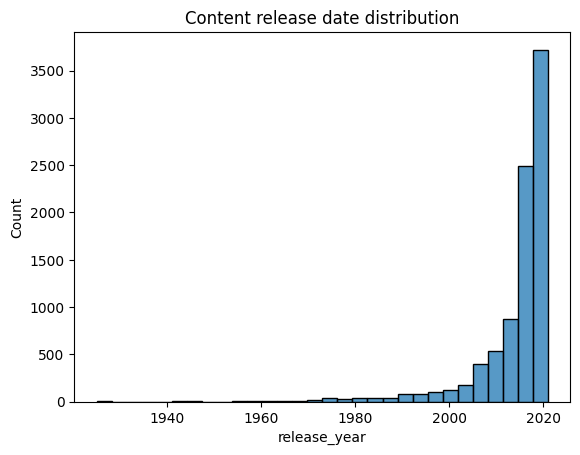

In [ ]:
sns.histplot(data=df['release_year'], bins=30)
plt.title('Content release date distribution')
plt.show()

### 6.3 Топ стран

In [ ]:
top_countries = df['country_main'].value_counts().head(10)
px.bar(x=top_countries.values, y=top_countries.index, title='Countries Top')

### 6.4 Топ жанров

In [53]:
top_genres = df['genre_main'].value_counts().head(10)
px.bar(top_genres.values, x=top_genres.values, y=top_genres.index, title='Genres Top')

### 6.5 Продолжительность фильмов

In [39]:
movies = df[df['type'] == 'Movie']
px.histogram(movies, x='duration_num', title='Movies Duration')

### 6.6 Возраст контента на момент добавления в Netflix

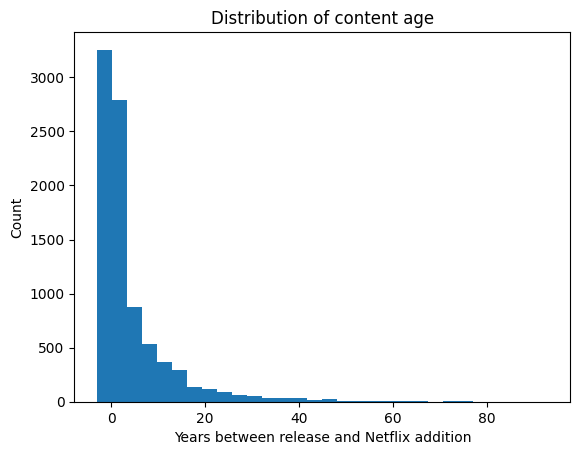

In [38]:
plt.hist(df['content-age'], bins=30)
plt.title('Distribution of content age')
plt.xlabel('Years between release and Netflix addition')
plt.ylabel('Count')
plt.show()

### 6.7 Количество сезонов в сериалах

In [55]:
series = df[df['type'] == 'TV Show']
px.histogram(series, x='duration_num', title='Seasons amount')

## 6.8 Дата выхода на платформу

In [57]:
px.histogram(df['date_added'], x=df['date_added'].dt.year)

## 7. Расширенная статистика
### 7.1 Статистика по длительности фильмов

In [ ]:
movies['duration_num'].min()
movies['duration_num'].max()
movies['duration_num'].mode()
movies['duration_num'].median()
movies['duration_num'].mean()
movies['duration_num'].quantile([0.25, 0.5, 0.75])

np.float64(98.0)

## 8. Feature Engineering
### 8.1 OneHot Encoding

In [43]:
df['type'].head()
df_encoded = pd.get_dummies(df, columns=['type', 'rating'], drop_first=False)
df_encoded['type_TV Show']

0       False
1        True
2        True
3        True
4        True
        ...  
8802    False
8803     True
8804    False
8805    False
8806    False
Name: type_TV Show, Length: 8807, dtype: bool

In [51]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num,duration_type,genre_main,country_main,content-age
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,min,Documentaries,United States,1.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,Seasons,International TV Shows,South Africa,0.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0,Season,Crime TV Shows,Unknown,0.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0,Season,Docuseries,Unknown,0.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0,Seasons,International TV Shows,India,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",158.0,min,Cult Movies,United States,12.0
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2.0,Seasons,Kids' TV,Unknown,1.0
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,88.0,min,Comedies,United States,10.0
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",88.0,min,Children & Family Movies,United States,14.0


## **Итоговые выводы**
### *Что я понял про датасет* :
- В датасете фильмов больше, чем TV Show
- Основной производитель фильмов - США
- Сейчас Нетфликс мгновенно добавляет контент на площадку
- Большинство фильмов имеет продолжительность 90-120 минут
- Драмы и комедии имеют преимущество среди всех жанров
- Большинство сериалов имеют 1-2 сезона
- Большая часть контента была добавлена в последние годы, что говорит о развитии платформы
### Дальнейшие действия
Дальше я бы обучал модели, которые предсказывают основной жанр фильма, дату выхода, рейтинг
